In [98]:
!pip install control

In [99]:
import control
import numpy as np
import matplotlib.pyplot as plt

In [100]:
numG =np.array([652.167])
denG = np.array([0.168, 1, 0])
G = control.tf(numG, denG)
print("G = ", G)

G =  <TransferFunction>: sys[25]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

      652.2
  -------------
  0.168 s^2 + s


Ahora, coloquemos las especificaciones de diseño

In [101]:
SP = 5 #5%
zeta = abs(np.log(SP/100)) / np.sqrt(np.log(SP/100)**2 + np.pi**2)
tr = 0.4 #s
wn = (2.23*zeta**2+0.036*zeta+1.54)/tr # rad/s
wn_min = 1/(0.12*(2*zeta+2))
wn_max = 0.25/0.01

print(wn)
print(zeta)
print(SP)
print(tr)
print(wn_min)
print(wn_max)

6.567188300819496
0.6901067305598217
5
0.4
2.465327538981235
25.0


Escribimos polinomio de ITAE

In [102]:
numT = np.array([wn**2])
denT = np.array([1, 1.4*wn, wn**2])
T = control.tf(numT, denT)
print("T = ", T)

T =  <TransferFunction>: sys[26]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

          43.13
  ---------------------
  s^2 + 9.194 s + 43.13


Calculemos ahora
$H_{(s)}$

In [103]:
numH = numT
denH = denT*numG
H = control.tf(numH,denH)
print(H)

<TransferFunction>: sys[27]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

              43.13
  ------------------------------
  652.2 s^2 + 5996 s + 2.813e+04


Orden del controlador, del polinomio ITAE, y de DHBarra:

In [104]:
n = 2 #Grado de la planta
vl = 1
m = n - 1 + vl#Grado del controlador

print("Entonces el controlador es de orden:", m)

ordenITAE = m+n

print("Entonces el polinomio de ITAE es de orden: ", ordenITAE)

ordenDHBarra = 2*n -1 + vl - 2

print("El orden de DHBarra: ", ordenDHBarra)

Entonces el controlador es de orden: 2
Entonces el polinomio de ITAE es de orden:  4
El orden de DHBarra:  2


Como buscamos PID, necesitamos controlador de la forma
$$
C(s) = \frac{B_2 s^2 + B_1s + B_0}{(A_2s^2 + A_1s + A_0)}
$$


Hallemos los polos de $T_{(S)}$ con el fin de colocar polos lejanos para que el orden cuadre. Ya que nuestro $T_{(S)}$ es de segundo orden, y debemos llevarlo a orden cuatro

In [105]:
polos = control.poles(T)
print(polos)
polosLejanos = np.real(polos[0])*2
print("Nuestros polos lejanos están en (s + ", abs(polosLejanos),")^2")
p = -polosLejanos
DHBarra = np.array([1, 2*p, p**2])
print("DHBarra = ", DHBarra)

[-4.59703181+4.68991052j -4.59703181-4.68991052j]
Nuestros polos lejanos están en (s +  9.194063621147292 )^2
DHBarra =  [ 1.         18.38812724 84.53080587]


Hallemos ahora $L_{(s)}$

In [106]:
L = numH * DHBarra
print("L = ", L)

L =  [  43.12796218  793.04245624 3645.64139846]


Hagamos la matriz

In [117]:
A_mat = np.array([
    [0.168, 0,    0,      0,      0],
    [1,    0.168, 0,      0,      0],
    [0,    1,    652.2, 0,      0],
    [0,    0,    0,      652.2, 0],
    [0,    0,    0,      0,      652.2]
])

sol = np.convolve(denH, DHBarra)
print(sol)
b_vec = np.array([
    sol[0],
    sol[1],
    sol[2],
    sol[3],
    sol[4]
])

# Resolver sistema
A2, A1, B2, B1, B0 = np.linalg.solve(A_mat, b_vec)

print(A2, A1, B2, B1, B0)
import numpy as np
import control

numC = (1/A2) * np.array([B2, B1, B0])
denC = (1/A2) * np.array([A2, A1, 0])

C = control.tf(numC, denC)
print(C)

[6.52167000e+02 1.79881947e+04 1.93511240e+05 1.02404832e+06
 2.37756701e+06]
3881.9464285714294 83965.76333492184 167.9630122508034 1570.1446131909745 3645.45693638372
<TransferFunction>: sys[52]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  0.04327 s^2 + 0.4045 s + 0.9391
  -------------------------------
           s^2 + 21.63 s


Polos del sistema de lazo cerrado [-4.59703181+4.68991052j -4.59703181-4.68991052j]
Denominador real: [[array([1.68000000e-01, 4.63380807e+00, 4.98475960e+01, 2.63784295e+02,
       6.12436765e+02])]]


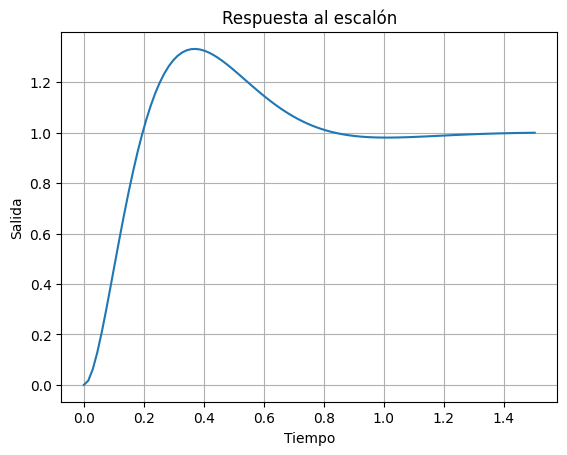

In [118]:
F = control.feedback(C*G,1)
print("Polos del sistema de lazo cerrado", control.poles(T))
print("Denominador real:", F.den)

t, y = control.step_response(F)
plt.plot(t,y)
plt.grid()
plt.title("Respuesta al escalón")
plt.xlabel("Tiempo")
plt.ylabel("Salida")
plt.show()